# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Pengaturan visualisasi dan mengabaikan peringatan
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Membaca dataset
df = pd.read_csv('data.csv')

# Menampilkan 5 baris pertama data
display(df.head())

# Menampilkan informasi kolom, tipe data, dan missing value
print("\nInformasi Dataset:")
df.info()

,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status,Creditworthiness
0,56,Female,Master,149406,34089,581,49200,60,4,Bad,Unemployed,Rented,Single,1
1,69,Female,High School,78896,8626,648,20147,24,7,Good,Employed,Mortgaged,Married,1
2,46,Female,Master,119339,46281,329,41307,12,8,Bad,Unemployed,Owned,Single,1
3,32,Male,High School,131067,29403,816,19019,60,8,Bad,Employed,Owned,Single,1
4,60,Male,PhD,38001,30032,673,16317,36,4,Average,Employed,Rented,Married,0



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                12000 non-null  int64 
 1   Gender             12000 non-null  object
 2   Education          12000 non-null  object
 3   Income             12000 non-null  int64 
 4   Debt               12000 non-null  int64 
 5   Credit_Score       12000 non-null  int64 
 6   Loan_Amount        12000 non-null  int64 
 7   Loan_Term          12000 non-null  int64 
 8   Num_Credit_Cards   12000 non-null  int64 
 9   Payment_History    12000 non-null  object
 10  Employment_Status  12000 non-null  object
 11  Residence_Type     12000 non-null  object
 12  Marital_Status     12000 non-null  object
 13  Creditworthiness   12000 non-null  int64 
dtypes: int64(8), object(6)
memory usage: 1.3+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah data kosong per kolom:
 Age                  0
Gender               0
Education            0
Income               0
Debt                 0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Num_Credit_Cards     0
Payment_History      0
Employment_Status    0
Residence_Type       0
Marital_Status       0
Creditworthiness     0
dtype: int64


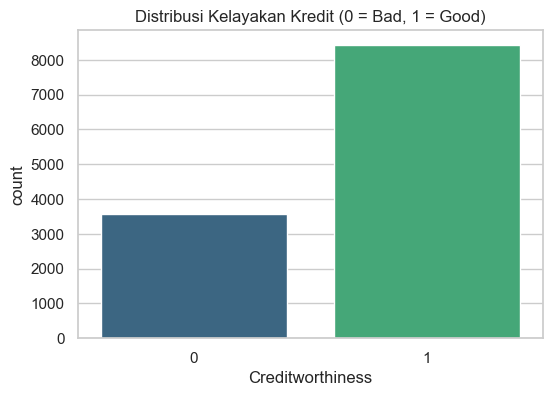

In [3]:
# Mengecek nilai yang kosong (missing values)
print("Jumlah data kosong per kolom:\n", df.isnull().sum())

# Menampilkan grafik distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Creditworthiness', palette='viridis')
plt.title('Distribusi Kelayakan Kredit (0 = Bad, 1 = Good)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Memisahkan Fitur (X) dan Target/Label (y)
X = df.drop('Creditworthiness', axis=1)
y = df['Creditworthiness']

# 2. Encoding: Mengubah tipe data teks/object menjadi angka
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# 3. Scaling: Menyamakan rentang nilai (Standardization)
numeric_cols = X.columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mengembalikan array numpy hasil scaling menjadi DataFrame kembali
X_final = pd.DataFrame(X_scaled, columns=numeric_cols)

# 4. Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Pesan sukses dan pengecekan akhir
print("✅ Data Preprocessing Selesai!")
print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
display(X_train.head())

✅ Data Preprocessing Selesai!
Ukuran X_train: (9600, 13)
Ukuran X_test: (2400, 13)


,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status
9182,0.973330,1.002002,-1.342266,0.278146,1.634390,0.000205,1.577724,1.418083,0.776666,-1.238504,1.227872,-1.226520,-1.223217
11091,-0.032817,-0.998002,0.441970,0.361810,1.691819,0.082583,-0.044429,0.003360,0.776666,-0.011756,-1.228691,-1.226520,1.228119
6428,0.034259,1.002002,0.441970,0.804177,-0.762889,-1.343187,0.856705,-1.411363,-0.765740,1.214991,-1.228691,1.230821,0.002451
288,-1.307270,1.002002,-1.342266,-0.022743,-1.394331,1.058444,0.418843,0.710721,1.547869,-0.011756,1.227872,-1.226520,1.228119
2626,0.168412,-0.998002,-0.450148,-0.701224,-1.135508,-0.443367,-1.659492,0.003360,-1.151342,-1.238504,-0.000409,1.230821,1.228119
